# Rough Bergomi Model results 
---
This notebook presents the results of a model trained on the **Rough Bergomi Model**.

---
Google Colab case

If you run this notebook on Google Colab, the utils folder is not available by default.
You must therefore download the utils.zip file provided with this notebook and then run the next cell, which extracts the archive and makes the utils folder accessible to Python.

Local case

If you already have the utils folder in the correct location, or if your environment is properly configured,
you can leave the next cell as is, or simply keep it commented.

In [ ]:
import os

BASE = "/content"
os.chdir(BASE)
print("Working directory:", os.getcwd())

# If utils directory does not exist, unzip it
if not os.path.isdir(os.path.join(BASE, "utils")):
    !unzip "utils.zip" -d /content


In [2]:
import torch
import torch.nn as nn

__dtype__ = torch.float32
__device__ = torch.device('cuda:0')

print("GPU available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("CUDA (PyTorch) :", torch.version.cuda)
    print("cuDNN :", torch.backends.cudnn.version())

!nvidia-smi

GPU available : True
GPU : Tesla V100-SXM2-32GB
CUDA (PyTorch) : 12.1
cuDNN : 8902
Tue Jan 13 13:57:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.51.03              Driver Version: 575.51.03      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-SXM2-32GB           Off |   00000000:18:00.0 Off |                    0 |
| N/A   46C    P0             59W /  300W |   11200MiB /  32768MiB |      0%      Default |
|                                         |              

$$
\textbf{Neural Network Generator}
$$

---

### **Overview**

The **`Generator`** class defines a **neural network-based generative model** designed to produce synthetic samples conditioned on **stochastic noise** and **input parameters**.

This generator maps **random noise** and **model parameters** to **a single output value**, effectively learning to generate a distribution that mimics a target process.

---

### **Architecture**
The generator follows a **feedforward neural network** structure:
1. **Inputs**:  
   - **Noise vector** of size **`noise_size`** (random component).  
   - **Model parameters** of size **`param_size`** (conditioning information).  
2. **Feature Transformations**:  
   - The noise and parameter inputs are **independently projected** to higher dimensions using linear layers:  
     - Noise is mapped to **`noise_dim`**.  
     - Parameters are mapped to **`param_dim_G`**.  
   - The transformed features are concatenated.
3. **Feedforward Layers**:  
   - The concatenated features pass through **`nb_hidden_layers_G`** hidden layers, each with **`hidden_dim_G`** neurons.  
   - Each layer applies:  
     - A **linear transformation**.  
     - A **Softplus activation** function for smooth non-linearity.
4. **Output Layer**:  
   - A final linear layer produces **a single output**.  
   - The final activation function is **Identity**, meaning no transformation is applied to the output.

### **Network representation**

$$
\begin{array}{ccc}
\textbf{Noise Input} & & \textbf{Parameter Input} \\
(\text{size} = \text{noise\_size}) & & (\text{size} = \text{param\_size}) \\
\downarrow & & \downarrow \\
\text{Linear Layer} & & \text{Linear Layer} \\
(\text{noise\_size} \to \text{noise\_dim}) & & (\text{param\_size} \to \text{param\_dim}) \\
\searrow & & \swarrow \\
\end{array}
$$

$$
\begin{array}{c}
\textbf{Concatenation} \\
\downarrow \\
\text{Linear Layer + Softplus} \quad ( \text{noise\_dim + param\_dim} \to \text{hidden\_dim}) \\
\downarrow \\
\text{Hidden Layers + Softplus} \quad (\text{hidden\_dim} \to \text{hidden\_dim}) \\
\downarrow \\
\textbf{Final Linear Layer} \quad (\text{hidden\_dim} \to 1) \\
\downarrow \\
\textbf{Output (Single Generated Value)}
\end{array}
$$


In [3]:
class Generator(nn.Module):
    def __init__(self,
                 noise_size: int=1,  # Size of the noise input
                 param_size: int=1,  # Size of the parameter input
                 noise_dim: int=50,  # Dimension after transforming noise input
                 param_dim_G: int=100,  # Dimension after transforming parameter input
                 hidden_dim_G: int=100,  # Number of neurons in hidden layers
                 nb_hidden_layers_G: int=1,  # Number of hidden layers
                 **kwargs):
        super(Generator, self).__init__()
        
        # Store model hyperparameters
        self.noise_size = noise_size
        self.param_size = param_size
        self.noise_dim = noise_dim
        self.param_dim = param_dim_G
        self.nb_hidden_layers = nb_hidden_layers_G
        self.hidden_dim = hidden_dim_G
        
        # Activation function (Softplus for smooth non-linearity)
        self.activation = torch.nn.Softplus(beta=10., threshold=20.0)
        
        # Linear transformations for noise and parameter inputs
        self.input_noise = nn.Linear(self.noise_size, self.noise_dim)
        self.input_param = nn.Linear(self.param_size, self.param_dim)
        
        # List to store hidden layers
        self.fcs = nn.ModuleList()
        for i in range(self.nb_hidden_layers):
            if i == 0:
                # First hidden layer connects transformed noise & parameter inputs
                self.fcs.append(nn.Linear(self.noise_dim + self.param_dim, self.hidden_dim))
            else:
                # Subsequent hidden layers
                self.fcs.append(nn.Linear(self.hidden_dim, self.hidden_dim))
        
        # Output layer (single neuron output)
        self.fcs.append(nn.Linear(self.hidden_dim, 1))
        
        # Final activation (Identity, meaning no transformation at output)
        self.final_activation = torch.nn.Identity()
        
        # Create the sequential model
        self.make_sequential()
    
    def make_sequential(self):
        """
        Constructs a sequential model from the list of layers and activations.
        """
        layers = []
        for i in range(self.nb_hidden_layers):
            layers.append(self.fcs[i])
            layers.append(self.activation)  # Apply activation after each hidden layer
        layers.append(self.fcs[-1])  # Final output layer
        layers.append(self.final_activation)  # No activation at the output
        
        self.M = nn.Sequential(*layers)
    
    def forward(self, x):
        """
        Forward pass of the generator.
        :param x: Input tensor containing both noise and parameters.
        :return: Generated output.
        """
        
        # Process noise and parameter inputs separately
        noise = self.input_noise(x[:, :self.noise_size])
        params = self.input_param(x[:, self.noise_size:])
        
        # Concatenate processed noise and parameter inputs
        x = torch.cat((noise, params), dim=1)
        
        # Pass through the sequential network
        return self.M(self.activation(x))



$$\textbf{Loading a Generator Model from a Checkpoint}$$

---

### **Overview**

The function **`load_generator_from_dir(dir_model)`** restores a previously trained **Generator** model by:
- Loading the model's saved state from a checkpoint.
- Extracting the required layer dimensions from the saved weights.
- Creating a new instance of the Generator with the extracted dimensions.
- Restoring the model's weights.


### **Visual Representation**

\begin{array}{c}
\text{Load Checkpoint} \\
\downarrow \\
\text{Extract Dimensions} \\
\downarrow \\
\text{Instantiate Generator Model} \\
\downarrow \\
\text{Load Weights} \\
\downarrow \\
\textbf{Generator Model Ready}
\end{array}



In [4]:
def load_generator_from_dir(dir_model):
    """
    Loads a Generator model from a saved checkpoint, extracting the necessary dimensions and restoring weights.
    :param dir_model: Path to the saved model checkpoint.
    :return: A Generator model with the loaded weights.
    """
    
    # Load the model file
    state_dict = torch.load(dir_model, map_location=torch.device('cpu'))
    
    # Extract layer dimensions from the state_dict
    noise_size = state_dict['input_noise.weight'].shape[1]  # Size of the noise input
    param_size = state_dict['input_param.weight'].shape[1]  # Size of the parameter input
    noise_dim = state_dict['input_noise.weight'].shape[0]   # Projected size of noise input
    param_dim_G = state_dict['input_param.weight'].shape[0] # Projected size of parameter input
    hidden_dim_G = state_dict['fcs.0.weight'].shape[0]      # Hidden layer size
    nb_hidden_layers_G = (len([k for k in state_dict.keys() if 'fcs' in k]) - 1) // 2  # Number of hidden layers
    
    # Create a new instance of the model with the extracted dimensions
    model = Generator(
        noise_size=noise_size,
        param_size=param_size,
        noise_dim=noise_dim,
        param_dim_G=param_dim_G,
        hidden_dim_G=hidden_dim_G,
        nb_hidden_layers_G=nb_hidden_layers_G
    )
    
    # Load the saved state_dict into the model
    model.load_state_dict(state_dict)
    
    return model

$$\textbf{rBergomi\_param: A Parameterized Dataset Class}$$

---

### **Overview**

The **`rBergomi_param`** class generates parameters for the rough Bergomi model simulations.  
It supports:
- **Random sampling**: Parameters are drawn from uniform distributions defined by `[param_min, param_max]`.
- **Deterministic mode**: A predefined list of values is used, and all possible **combinations** are generated via the Cartesian product.

---

### **How Parameter Generation Works?**

#### **🔹 Random Sampling Mode**
To generate parameters randomly, each parameter should be provided as a **list of two values**:

$$
[\text{param}_{\min}, \text{param}_{\max}]
$$

- A uniform distribution is used to sample values:

$$
X_{\text{sample}} \sim \mathcal{U}(\text{param}_{\min}, \text{param}_{\max})
$$

- This applies to **ALPHAS, ETAS, RHOS, v0, and T**.
- If a parameter is given as `[param]` of size 1, the same parameter is used for each sample (e.g., fixing `T`).
- Returns a tensor of size `nb_simu`.

#### **🔹 Non-Random Mode (Cartesian Product)**
To **generate all possible parameter combinations**, each parameter should be given as a list of discrete values:

$$
[\text{param}_1, \text{param}_2, \dots, \text{param}_n]
$$

- The dataset will compute the **Cartesian product** of all parameter lists:

$$
\text{params} = \text{Cartesian\_Product}(\alpha, \eta, \rho, v_0, T)
$$

- This ensures that every combination is present in the final dataset.

#### **🔹 Handling Initial Time $t_0$**
If `t0=True`, the function determines an initial time $t_0$ such that:
- $|T - t_0| \geq \text{min\_dt}$.
- If `fixed_dt=True`, $t_0$ is chosen deterministically.
- Otherwise, $t_0$ is randomly sampled from valid values.

---

### **Visual Representation**

$$
\begin{array}{c}
\text{Initialize Dataset} \\
\downarrow \\
\text{Convert Parameters to Tensors} \\
\downarrow \\
\textbf{If Random Sampling:} \\
\quad \text{Sample Uniformly Within These Ranges} \\
\quad \text{Stack Parameters into a Tensor} \\
\textbf{Else:} \\
\quad \text{Generate Cartesian Product of Parameter Values} \\
\downarrow \\
\text{Compute Initial Time } t_0 \text{ (if applicable)} \\
\downarrow \\
\text{Dataset Ready!}
\end{array}
$$

---

### **⚠️ Important Warning**
> 🚨 **This class does NOT generate the model itself!**  
> It only prepares and stores **parameter samples** for simulations.  
> The simulation is defined separately and will use these parameters.


In [5]:
from torch.utils.data import Dataset

class rBergomi_param(Dataset):
    """
    A dataset class for handling parameterized simulations based on the Bergomi model.
    This class generates a dataset with either random parameter sets or all possible parameter combinations 
    using a Cartesian product of the specified parameter lists.

    Parameters:
    - dtype: The data type for tensors (e.g., torch.float32).
    - device: The device where the tensors will be stored (e.g., CPU or GPU).
    - random_param: If True, generates random parameter samples. If False, uses a full Cartesian product of all possible parameters.
    - ALPHAS, ETAS, RHOS, v0, T: Lists of possible values for each model parameter.
    - t0: If True, includes an initial time parameter in the simulations.
    - min_dt: Minimum value of |T - t0|
    - fixed_dt:  True if |T- t0| is constant else False
    - N_steps: Number of time steps in the simulation.
    - nb_simu: Number of simulations.
    """

    def __init__(self,
                 dtype,
                 device: torch.device = torch.device('cuda:0'),
                 random_param: bool=False,
                 ALPHAS: object=[1.],
                 ETAS: object=[1.],
                 RHOS: object=[1.],
                 v0: object=[1.],
                 T: object=[1.],
                 t0: bool=True,
                 min_dt: float=0.1,
                 fixed_dt: bool=True,
                 N_steps: int=100,                 
                 nb_simu: int=int(5e6),
                 **kwargs):
        
        self.dtype = dtype  
        self.device = device 
        self.random_param = random_param 
        self.ALPHAS = ALPHAS  
        self.ETAS = ETAS  
        self.RHOS = RHOS 
        self.v0 = v0
        self.T = T 
        self.t0 = t0  
        self.min_dt = min_dt 
        self.fixed_dt = fixed_dt  
        self.N_steps = N_steps
        self.nb_simu = nb_simu  
        self.make_params()  

    def __getitem__(self, index):
        """
        Returns the parameter set at the specified index.
        """
        return self.params[index]

    def __len__(self):
        """
        Returns the total number of simulations (parameter sets).
        """
        return self.nb_simu

    def make_params(self):
        """
        Converts parameter lists into tensors and generates the dataset.
        Handles both random parameter generation and full Cartesian product generation.
        """
        # Convert parameter lists to tensors
        self.ALPHAS_torch = torch.tensor(self.ALPHAS, dtype=self.dtype, device=self.device)
        self.ETAS_torch = torch.tensor(self.ETAS, dtype=self.dtype, device=self.device)
        self.RHOS_torch = torch.tensor(self.RHOS, dtype=self.dtype, device=self.device)
        self.v0_torch = torch.tensor(self.v0, dtype=self.dtype, device=self.device)
        self.T_torch = torch.tensor(self.T, dtype=self.dtype, device=self.device)

        if self.random_param:
            # Generate random parameters for each simulation
            self.nb_simu = self.nb_simu  # Number of simulations
            
            # Sampling ALPHAS
            if len(self.ALPHAS_torch) == 1:
                self.ALPHAS_sample = self.ALPHAS_torch.repeat(self.nb_simu)
            else:
                self.ALPHAS_sample = torch.distributions.Uniform(self.ALPHAS_torch[0], self.ALPHAS_torch[-1]).sample((self.nb_simu,))
            
            # Sampling ETAS
            if len(self.ETAS_torch) == 1:
                self.ETAS_sample = self.ETAS_torch.repeat(self.nb_simu)
            else:
                self.ETAS_sample = torch.distributions.Uniform(self.ETAS_torch[0], self.ETAS_torch[-1]).sample((self.nb_simu,))
            
            # Sampling RHOS
            if len(self.RHOS_torch) == 1:
                self.RHOS_sample = self.RHOS_torch.repeat(self.nb_simu)
            else:
                self.RHOS_sample = torch.distributions.Uniform(self.RHOS_torch[0], self.RHOS_torch[-1]).sample((self.nb_simu,))
            
            # Sampling v0
            if len(self.v0_torch) == 1:
                self.v0_sample = self.v0_torch.repeat(self.nb_simu)
            else:
                self.v0_sample = torch.distributions.Uniform(self.v0_torch[0], self.v0_torch[-1]).sample((self.nb_simu,))
            
            # Sampling T
            if len(self.T_torch) == 1:
                self.T_sample = self.T_torch.repeat(self.nb_simu)
            else:
                self.T_sample = torch.distributions.Uniform(self.T_torch[0], self.T_torch[-1]).sample((self.nb_simu,))
            
            # Stack all sampled parameters into one tensor
            self.params_stack = torch.stack((self.ALPHAS_sample, self.ETAS_sample, self.RHOS_sample, self.v0_sample, self.T_sample))
            
            # Transpose the stacked parameters to arrange them as [nb_simu, 5]
            self.params = self.params_stack.T
        else:
            # If random_param is False, generate all possible combinations using Cartesian product
            self.params = torch.cartesian_prod(self.ALPHAS_torch, self.ETAS_torch, self.RHOS_torch, self.v0_torch, self.T_torch)
            self.nb_simu = len(self.params)  # Set the number of simulations to the total number of combinations
            self.T_sample = self.params.T[-1]  # Extract the T parameter

        if self.t0:
            # looking for t0 in the grid such that |T-t0| >= min_dt
            grid = torch.linspace(0, 1, self.N_steps + 1, dtype=self.dtype, device=self.device).unsqueeze(0)  
            dt_grid = grid * self.T_sample.unsqueeze(1)  # Multiply grid by each simulation's T parameter
            valid_t = dt_grid <= (self.T_sample - self.min_dt).unsqueeze(1)  # Check if the time step is valid
            nb_valid_t = torch.sum(valid_t, dim=1)  # Count valid time steps
            
            if self.fixed_dt:
                # Use fixed time steps based on the valid time steps
                self.t0_sample = dt_grid[torch.arange(self.nb_simu, device=self.device), nb_valid_t]
            else:
                # If not fixed, select a random time step
                index = (torch.rand(self.nb_simu, device=self.device) * nb_valid_t.float()).int()
                self.t0_sample = dt_grid[torch.arange(self.nb_simu, device=self.device), index]
            
            # Concatenate the parameters with the generated initial time (t0)
            self.params = torch.cat((self.params[:, :-1], self.t0_sample.unsqueeze(0).T, self.params[:, -1].unsqueeze(1)), dim=1)


## Simulation of the rough Bergomi model

This section describes the benchmark numerical scheme used to simulate the rough Bergomi model.  
The implementation follows the hybrid scheme introduced in Bennedsen, Lunde and Pakkanen (2017), which provides an efficient approximation of fractional Brownian motion–driven volatility.

---

### Model definition

The rough Bergomi model is defined by

$$
S_T = \exp\!\left(\int_0^T \sqrt{V_t}\, dW_t^1 - \tfrac{1}{2}\int_0^T V_t\, dt\right),
$$

with variance process

$$
V_t = v_0 \exp\!\left(\eta W_t^H - \tfrac{1}{2}\eta^2 t^{2\alpha+1}\right),
$$

where $W_t^H$ is a fractional Brownian motion with Hurst parameter $H = \alpha + \tfrac{1}{2}$.

---

### Hybrid approximation of the fractional Brownian motion

The fractional Brownian motion is approximated using the hybrid representation

$$
W_t^H \approx Y_t^1 + Y_t^2,
$$

where  
$Y_t^1$ is constructed directly from Brownian increments, and  
$Y_t^2$ is obtained via a discrete convolution designed to capture the long-memory structure.

This decomposition is implemented through a convolution kernel depending on $\alpha$, following the construction in Bennedsen et al. (2017).

---

### Path construction

The simulation is performed on a uniform time grid with step size $\Delta t$.  
Let $\Delta X_j$ denote the log-price increment at time step $j$:

$$
\Delta X_j = \sqrt{V_{t_j}}\, \Delta W_j^1 - \tfrac{1}{2} V_{t_j}\, \Delta t.
$$

The terminal value is obtained by summation:

$$
\log S_T = \sum_{j} \Delta X_j.
$$

When different trajectories have different maturities $T_i$, all paths are simulated up to $\max(T)$ and a mask is applied so that each trajectory only accumulates increments up to its own final time.

---

### Output

The function returns a tensor $S$ of size $N$, where each entry corresponds to one independent realization of the rough Bergomi model evaluated at its associated maturity $T_i$.

This implementation serves as a numerical benchmark for validating generative models trained to reproduce rough Bergomi dynamics.


In [6]:
# Benchmark method
from torch.distributions.multivariate_normal import MultivariateNormal
import torch.nn.functional as F


def g(x, alpha):
    """
    Function g(x, alpha) computes x raised to the power of alpha.
    
    Arguments:
    - x: Tensor representing the input value.
    - alpha: Scalar or tensor that is used as the exponent.
    
    Returns:
    - The result of x raised to the power of alpha (x^alpha).
    """
    return x**alpha

def b(k, alpha):
    """
    Function b(k, alpha) computes the normalized power of the difference of (k^(alpha+1)) and ((k-1)^(alpha+1)).
    
    Arguments:
    - k: Tensor representing the input values.
    - alpha: Scalar or tensor that is used in the exponentiation and normalization.
    
    Returns:
    - The computed value based on the given formula.
    """
    return ((k**(alpha+1)-(k-1)**(alpha+1))/(alpha+1))**(1/alpha)

def correl(alpha, dt, dtype = torch.float32, device = torch.device('cpu')) :
    """
    Function to compute the correlation matrix used in the rough Bergomi model.
    
    Arguments:
    - alpha: Tensor of exponents used in the correlation calculation.
    - dt: Time step size.
    - dtype: Data type for the resulting tensor (default is torch.float32).
    - device: The device on which the tensor will be stored (default is CPU).
    
    Returns:
    - The correlation matrix as a tensor with shape (alpha.size(0), 2, 2).
    """
    # Initialize the correlation matrix with zeros
    c = torch.zeros((alpha.view(-1).shape[0], 2, 2), dtype=dtype, device=device)
    c[:,0,0] = dt  # Diagonal element for time step
    c[:,1,0] = 1./((1.*alpha+1) * (1/dt)**(1.*alpha+1))  # Off-diagonal element for correlation
    c[:,1,1] = 1./((2.*alpha+1) * (1/dt)**(2.*alpha+1))  # Another off-diagonal element for correlation
    c[:,0,1] = c[:,1,0]  # Symmetry in the correlation matrix
    return c

def rBergomi(alpha, eta, rho, v0, t0, T, dt, dtype = torch.float32, device = torch.device('cpu')) :
    """
    This function simulates the rough Bergomi model based on the parameters provided.
    It generates paths for a rough volatility model and computes asset prices using
    the rough Bergomi dynamics.
    
    Arguments:
    - alpha: The Hurst exponent (roughness parameter).
    - eta: Volatility of volatility (vol of vol).
    - rho: Correlation between Brownian motions for asset and volatility.
    - v0: Initial volatility value.
    - t0: Initial time (start of the simulation).
    - T: End time of the simulation.
    - dt: Time step size for the simulation.
    - dtype: Data type for the tensors (default is torch.float32).
    - device: Device on which tensors will be allocated (default is CPU).
    
    Returns:
    - The simulated asset path (S_integral), computed using the rough Bergomi model.
    """
    # Calculate the number of time steps based on T and dt
    N_steps = torch.round(torch.max(T)/dt).to(torch.int32)
    N_traj = T.shape[0]  # Number of trajectories or simulations
    
    # Initialize the volatility path Y1 (first component of rough volatility)
    Y1 = torch.zeros(N_steps+1, N_traj, dtype=dtype, device=device)
    
    # Generate correlated random variables using Multivariate Normal distribution
    dW = MultivariateNormal(torch.zeros(N_traj, 2, dtype=dtype, device=device), correl(alpha, dt, dtype, device)).sample((N_steps,))
    
    # Assign the second component of the random walk to Y1
    Y1[1:] = dW[:, :, 1]

    # Initialize Gamma path (second component of rough volatility process)
    Gamma = torch.zeros(N_traj, N_steps+1, dtype=dtype, device=device)
    arange = torch.arange(2, N_steps+1, dtype=dtype, device=device)
    
    # Calculate Gamma using the formula for rough Bergomi model
    G = g(b(arange, alpha.view(-1,1))*dt, alpha.view(-1,1))
    Gamma[:,2:] = G

    # Extract the first component of the random walk (Ksi)
    Ksi = dW[:,:,0].t()
    
    # Reshape Gamma and Ksi for convolution
    Gamma_conv = Gamma.unsqueeze(1).view(1, N_traj, -1)  
    Ksi_conv = Ksi.unsqueeze(1).flip([2]).view(N_traj, 1, -1)  
    
    # Apply convolution to simulate the second volatility component
    padding = Ksi_conv.shape[2] - 1
    conv = F.conv1d(Gamma_conv, Ksi_conv, padding=padding, groups=N_traj).squeeze()
    Y2 = conv[:, : N_steps+1].t()
    
    # Combine the two components of volatility
    Y = torch.sqrt(2 * alpha + 1) * (Y1 + Y2)
    
    # Time grid and stochastic exponential calculation
    t = (torch.arange(0, N_steps + 1, dtype=dtype, device=device).unsqueeze(1)) * dt
    V = v0 * torch.exp((eta * Y) - eta**2 / 2 * t**(2*alpha+1))
    
    # Simulate the random walk for the asset price
    dW2 = torch.sqrt(torch.tensor(dt)) * torch.randn((N_steps, N_traj), dtype=dtype, device=device)
    dW2 = rho * dW[:,:,0] + torch.sqrt(1-rho**2) * dW2
    
    # Increment for the asset price (S_increment)
    S_increment = torch.sqrt(V[:-1]) * dW2 - 0.5 * V[:-1] * dt
    
    # Mask the increments that are outside the time boundary
    indices = torch.arange(N_steps, device=device).expand((N_traj,-1))
    mask = indices <= torch.round(T/dt).view(-1,1)
    S_increment = S_increment * mask.T
    
    # Adjust for time grid
    
    grid = torch.linspace(0, 1, N_steps+1, dtype=dtype, device=device)[:-1].unsqueeze(0)  
    dt_grid = grid * torch.max(T)
    mask = (dt_grid >= t0.unsqueeze(1))
    S_increment = S_increment * mask.T
    
    # Sum the increments to get the final asset price path
    S_integral = S_increment.sum(dim=0)
    
    return S_integral


### Marginal distribution comparison for the rough Bergomi model

The function `show_marginal` compares the marginal distributions generated by the trained model with those obtained from the benchmark rough Bergomi simulation.

For each parameter configuration, a large number of independent terminal samples are generated using:
- the benchmark rough Bergomi simulator,
- the learned generator model.

Let $S^{\text{true}}$ and $S^{\text{model}}$ denote the corresponding terminal asset prices.  
Both outputs are exponentiated to recover prices and clipped to a fixed cap for numerical stability and visual clarity.

The discrepancy between the two marginal distributions is quantified using the 1-Wasserstein distance

$$
W_1\!\left(S^{\text{true}},\, S^{\text{model}}\right).
$$

#### Procedure

1. Generate $N_{\text{traj}}$ terminal samples from the benchmark rough Bergomi model.
2. Generate $N_{\text{traj}}$ terminal samples from the generator using random noise and physical parameters.
3. Exponentiate and clip both samples.
4. Estimate and plot kernel density estimates of the two distributions.
5. Compute and report the Wasserstein distance.

#### Output

For each parameter set, the function displays a density comparison plot and reports the corresponding Wasserstein distance, providing a direct visual and quantitative assessment of the marginal accuracy of the generator.
e marginal distributions of the target rBergomi process.



In [7]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance as w1
import os

@torch.no_grad()
def show_marginal(model, dataset, N_traj=20000, dt=0.001, noise_size=5,
                  cap=3.0, dtype=torch.float32, device=torch.device("cpu"),
                  save_fig_dir=""):
    """
    Visual comparison between true and model-generated marginal distributions.

    Parameters:
    - model: Trained generator model.
    - dataset: Tensor of shape [n_samples, param_dim] containing physical parameters.
    - N_traj: Number of trajectories per parameter set.
    - dt: Time step for simulation.
    - noise_size: Dimensionality of the noise input to the GAN.
    - cap: Maximum value to clip output for display.
    - dtype: Data type for tensors.
    - device: Device used for computations.
    - save_fig_dir: Optional directory path to save plots.
    """
    model = model.to(device).eval()

    if save_fig_dir:
        os.makedirs(save_fig_dir, exist_ok=True)

    for i, param in enumerate(dataset):
        input_param = param.expand(N_traj, -1).T

        true_sample = rBergomi(*input_param, dt=dt, dtype=dtype, device=device)
        true_sample = true_sample.clamp(max=cap).to("cpu")
        true_sample = torch.exp(true_sample)

        noise = torch.rand(N_traj, noise_size, device=device)
        gan_input = torch.cat([noise, param.unsqueeze(0).expand(N_traj, -1)], dim=1)
        model_sample = model(gan_input).detach().view(-1).clamp(max=cap).cpu()
        model_sample = torch.exp(model_sample)

        W = w1(true_sample.numpy(), model_sample.numpy())

        alpha, eta, rho, v0, t0, T = param.tolist()
        print(f"\n📌 Parameter set {i + 1}")
        print(f"    α = {alpha:.3f}   η = {eta:.3f}   ρ = {rho:.3f}   ν₀ = {v0:.3f}   t₀ = {t0:.3f}   T = {T:.3f}")
        print(f"    📏 Wasserstein distance: {W:.4f}")

        fig, ax = plt.subplots(figsize=(9, 4.5))
        sns.kdeplot(true_sample.numpy(), color="navy", lw=2, label="True rBergomi",
                    alpha=0.8, ax=ax, clip=(0.0, cap))
        
        sns.kdeplot(model_sample.numpy(), color="crimson", lw=2, label="GAN",
                    linestyle="--", alpha=0.8, ax=ax, clip=(0.0, cap))
        ax.set_title(f"Marginal distribution comparison (Set {i + 1})", fontsize=20)
        ax.set_xlabel("Sample Value", fontsize=20)
        ax.set_ylabel("Density", fontsize=20)
        ax.legend(fontsize=20)
        ax.grid(True, linestyle='--', linewidth=0.8, alpha=0.6, color="#555555")
        plt.tight_layout()
        
        if save_fig_dir:
            filename = f"rBergomi_set{i+1}_alpha{alpha:.2f}_eta{eta:.2f}_rho{rho:.2f}_v0{v0:.2f}_t0{t0:.2f}_T{T:.2f}.eps"
            filepath = os.path.join(save_fig_dir, filename.replace(" ", "").replace(":", ""))
            plt.savefig(filepath, format="eps", dpi=300)
            print(f"📸 Figure saved to: {filepath}")

        plt.show()


$$
\textbf{Load the model}
$$

In [8]:
dir_model = "utils/models/rBergomi_model(GAN).pt" # directory containing the model
model = load_generator_from_dir(dir_model)  # rebuild the model
model.to(__device__) 
model.eval() 

Generator(
  (activation): Softplus(beta=10.0, threshold=20.0)
  (input_noise): Linear(in_features=5, out_features=150, bias=True)
  (input_param): Linear(in_features=6, out_features=150, bias=True)
  (fcs): ModuleList(
    (0-2): 3 x Linear(in_features=300, out_features=300, bias=True)
    (3): Linear(in_features=300, out_features=1, bias=True)
  )
  (final_activation): Identity()
  (M): Sequential(
    (0): Linear(in_features=300, out_features=300, bias=True)
    (1): Softplus(beta=10.0, threshold=20.0)
    (2): Linear(in_features=300, out_features=300, bias=True)
    (3): Softplus(beta=10.0, threshold=20.0)
    (4): Linear(in_features=300, out_features=300, bias=True)
    (5): Softplus(beta=10.0, threshold=20.0)
    (6): Linear(in_features=300, out_features=1, bias=True)
    (7): Identity()
  )
)

### Extreme parameter testing

This experiment evaluates the generator on parameter configurations located at the boundaries of its training domain.

The model is trained over the following parameter ranges:

$$
\alpha \in [-0.49,\,-0.10], \qquad
\eta \in [1.0,\,3.0], \qquad
\rho \in [-0.95,\,-0.30], \qquad
v_0 \in [0.01,\,0.12], \qquad
T \in \left[\tfrac{30}{365},\,\tfrac{185}{365}\right].
$$

In addition, the initial time $t_0$ is included as a model parameter and satisfies the constraints

$$
t_0 \ge 0,
\qquad
|T - t_0| \ge \tfrac{30}{365}.
$$

The selected parameter sets correspond to extreme combinations of $\alpha$, $\eta$, $\rho$, $v_0$,  $t_0$, $T$, and are used to assess the robustness and stability of the learned generator $G$ near the edges of the training support.



📌 Parameter set 1
    α = -0.450   η = 2.500   ρ = -0.900   ν₀ = 0.020   t₀ = 0.000   T = 0.082
    📏 Wasserstein distance: 0.0021


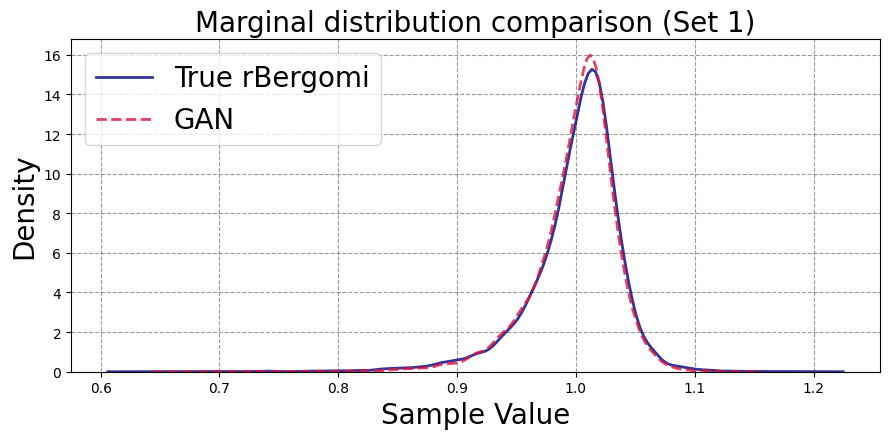


📌 Parameter set 2
    α = -0.100   η = 1.000   ρ = -0.300   ν₀ = 0.030   t₀ = 0.000   T = 0.082
    📏 Wasserstein distance: 0.0023


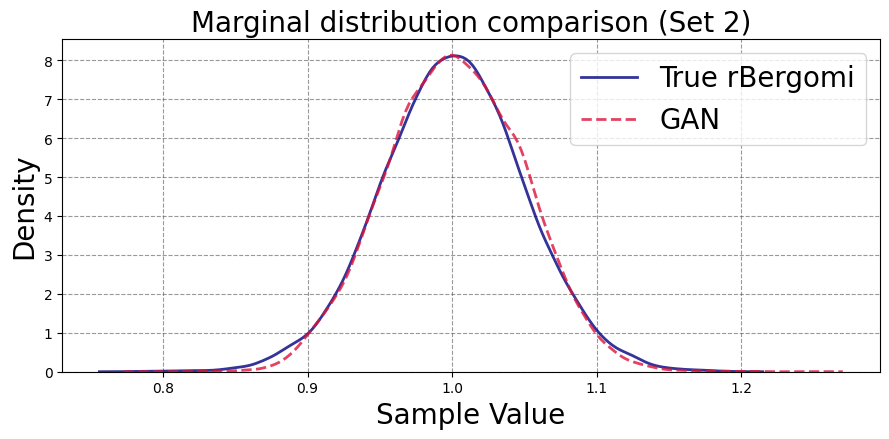


📌 Parameter set 3
    α = -0.450   η = 1.200   ρ = -0.900   ν₀ = 0.040   t₀ = 0.000   T = 0.082
    📏 Wasserstein distance: 0.0008


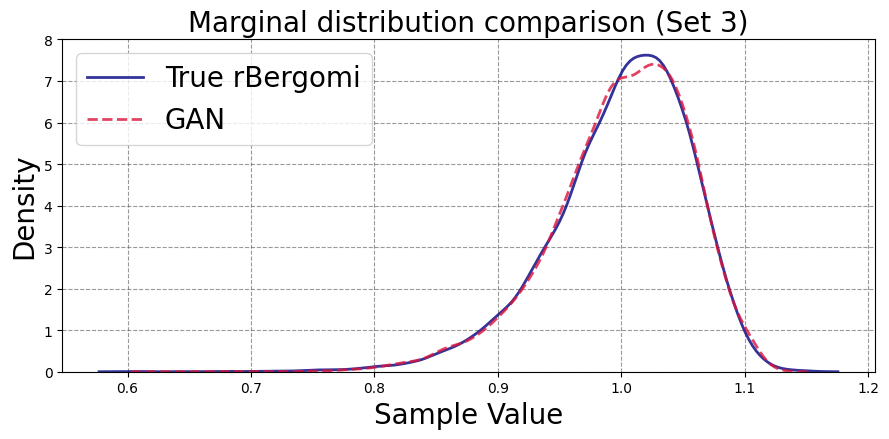


📌 Parameter set 4
    α = -0.100   η = 3.000   ρ = -0.300   ν₀ = 0.060   t₀ = 0.000   T = 0.493
    📏 Wasserstein distance: 0.0036


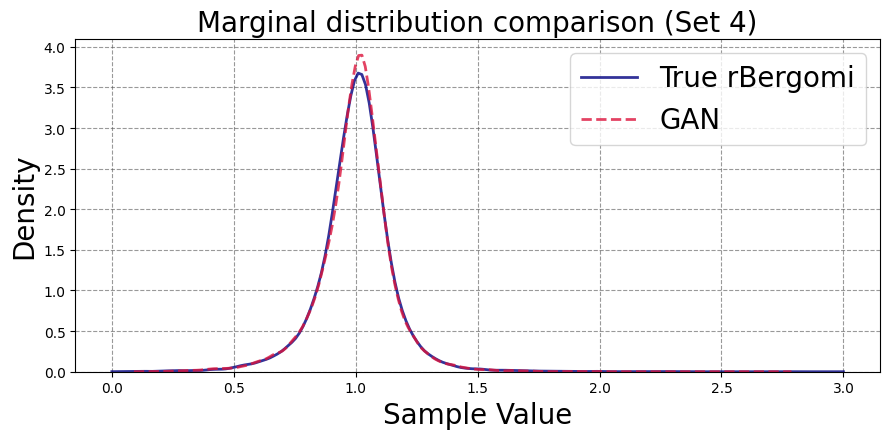


📌 Parameter set 5
    α = -0.450   η = 2.500   ρ = -0.300   ν₀ = 0.100   t₀ = 0.000   T = 0.493
    📏 Wasserstein distance: 0.0036


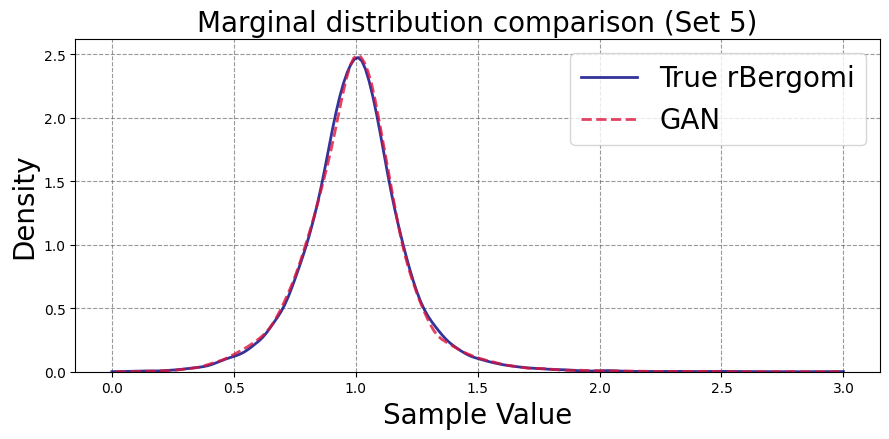


📌 Parameter set 6
    α = -0.100   η = 1.000   ρ = -0.900   ν₀ = 0.120   t₀ = 0.000   T = 0.493
    📏 Wasserstein distance: 0.0127


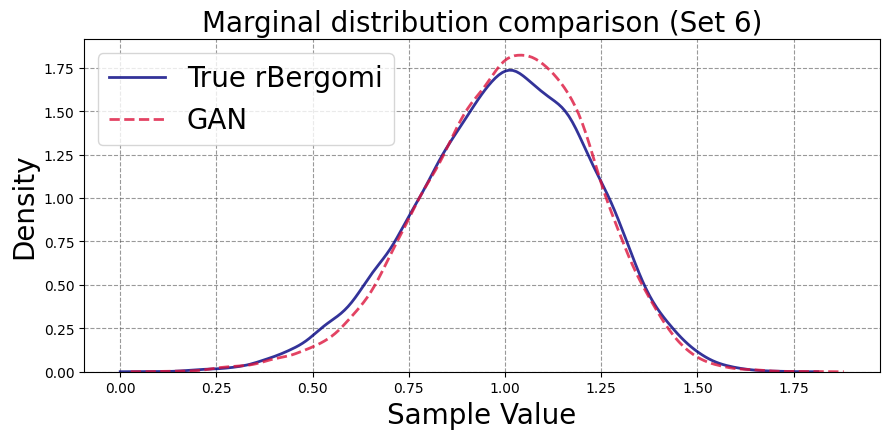

In [10]:
import torch
extreme_params = torch.tensor([
    [-0.45, 2.5, -0.9, 0.02, 0.0, 30/365],
    [-0.1, 1.0,  -0.3, 0.03, 0.0, 30/365],
    [-0.45, 1.2, -0.9, 0.04, 0.0, 30/365],
    [-0.1, 3.0,  -0.3, 0.06, 0.0, 180/365],
    [-0.45, 2.5,  -0.3, 0.1, 0.0, 180/365],
    [-0.10, 1.0, -0.9, 0.12, 0.0, 180/365],
], dtype=__dtype__, device=__device__)

show_marginal(
    model=model,
    dataset=extreme_params,
    device=__device__
)


### Typical parameter testing $(t_0=0)$

This experiment evaluates the generator on representative parameter configurations.

The typical settings are strictly chosen within the training parameter ranges and do not include any extrapolation outside the domain seen during training. They correspond to standard market regimes and are used to assess the in-domain accuracy of the learned generator $G$.



📌 Parameter set 1
    α = -0.450   η = 1.500   ρ = -0.800   ν₀ = 0.020   t₀ = 0.000   T = 0.082
    📏 Wasserstein distance: 0.0010


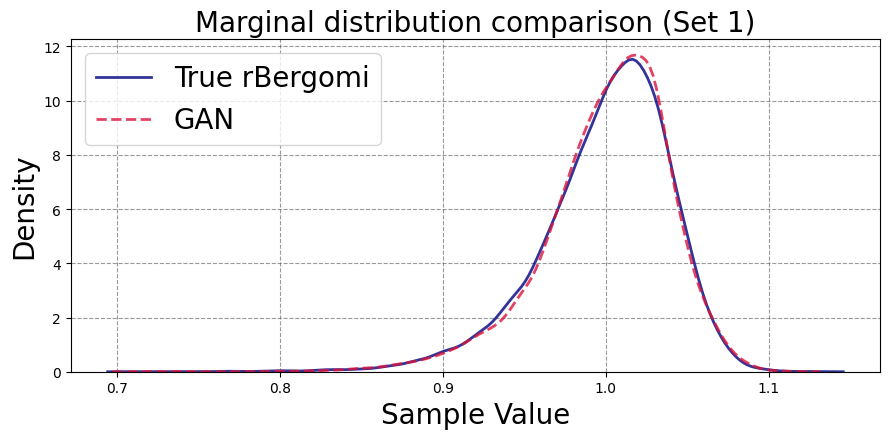


📌 Parameter set 2
    α = -0.300   η = 2.000   ρ = -0.700   ν₀ = 0.030   t₀ = 0.000   T = 0.247
    📏 Wasserstein distance: 0.0021


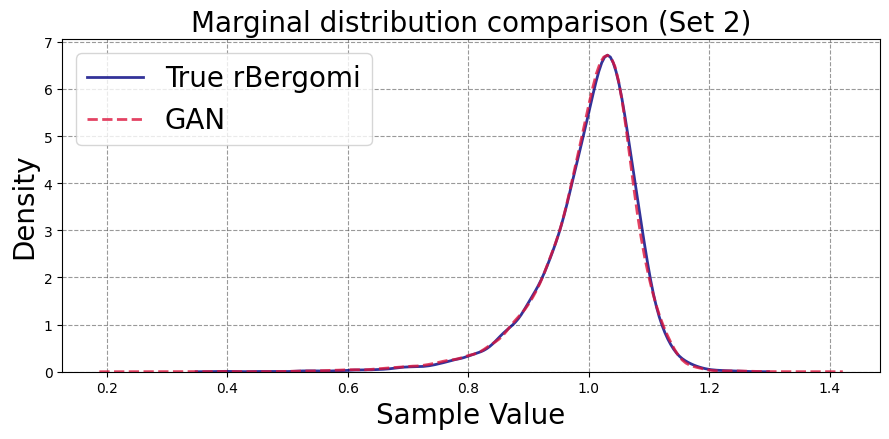


📌 Parameter set 3
    α = -0.450   η = 1.800   ρ = -0.900   ν₀ = 0.060   t₀ = 0.000   T = 0.329
    📏 Wasserstein distance: 0.0032


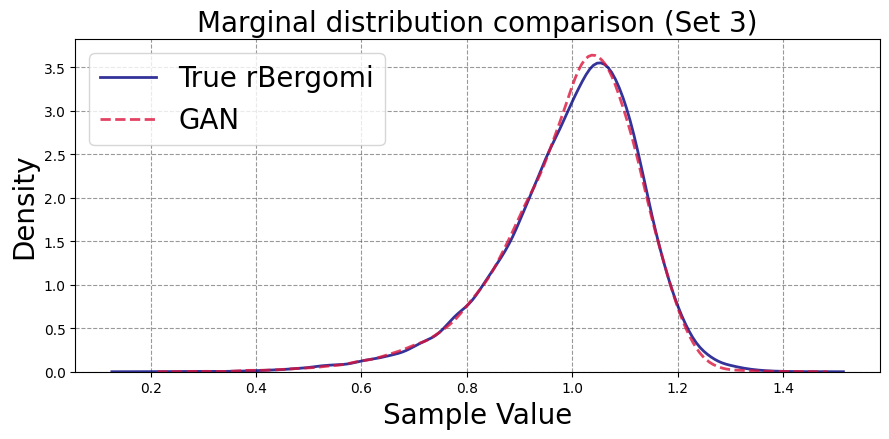


📌 Parameter set 4
    α = -0.350   η = 2.300   ρ = -0.400   ν₀ = 0.100   t₀ = 0.000   T = 0.411
    📏 Wasserstein distance: 0.0029


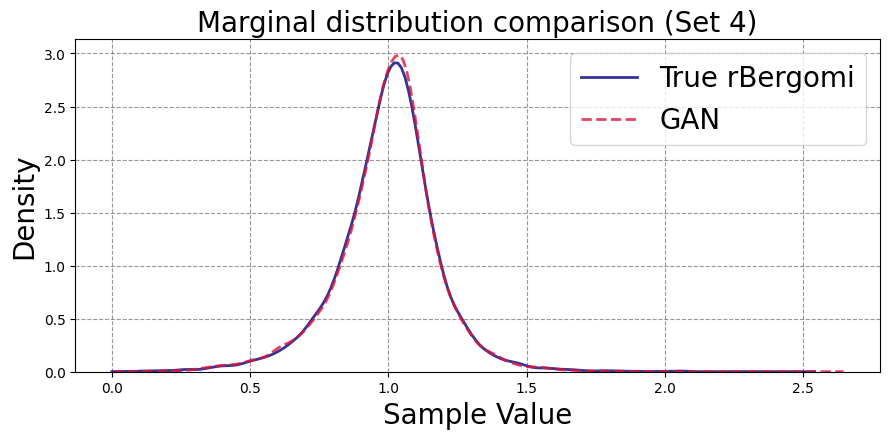


📌 Parameter set 5
    α = -0.250   η = 1.700   ρ = -0.600   ν₀ = 0.120   t₀ = 0.000   T = 0.493
    📏 Wasserstein distance: 0.0042


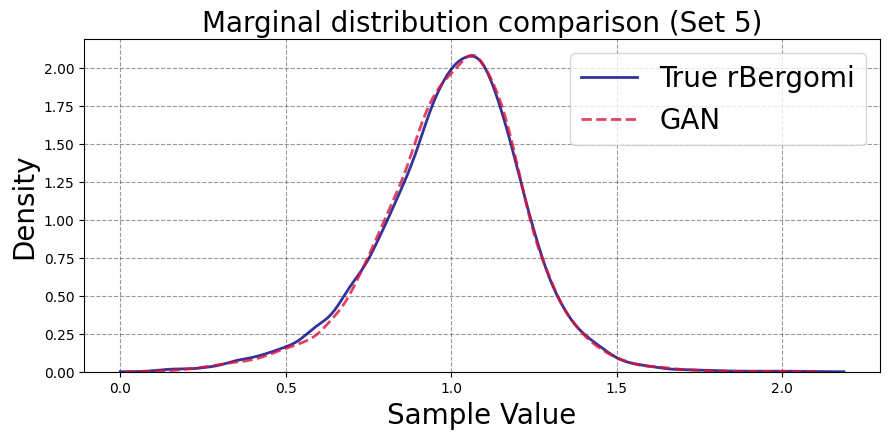


📌 Parameter set 6
    α = -0.400   η = 2.500   ρ = -0.700   ν₀ = 0.100   t₀ = 0.000   T = 0.274
    📏 Wasserstein distance: 0.0020


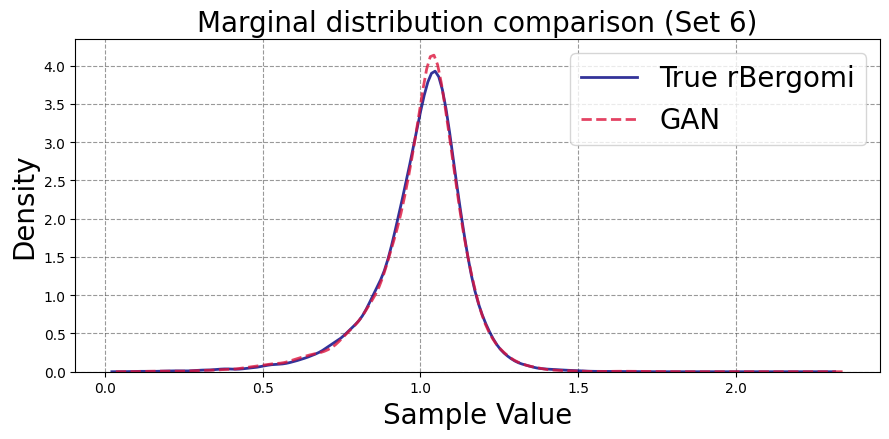

In [11]:
import torch
from datetime import date

# 📦 Paramètres du modèle rough Bergomi : cas typiques dans le domaine d'entraînement


# ✅ Typical scenarios for rough Bergomi model [alpha, eta, rho, v0, t0, T]
typical_params = torch.tensor([
    [-0.45, 1.5, -0.8, 0.02, 0.0, 30/365],
    [-0.30, 2.0, -0.7, 0.03, 0.0, 90/365],
    [-0.45, 1.8, -0.9, 0.06, 0.0, 120/365],
    [-0.35, 2.3, -0.4, 0.1, 0.0,  150/365],
    [-0.25, 1.7, -0.6, 0.12, 0.0, 180/365],
    [-0.4, 2.5, -0.7, 0.10, 0.0,  100/365],
], dtype=__dtype__, device=__device__)

# 📊 Visualisation des densités marginales simulées à partir des cas typiques
show_marginal(
    model=model,
    dataset=typical_params,
    dtype=__dtype__,
    device=__device__
)


### Typical parameter testing $(t_0 \ge 0)$

This experiment evaluates the generator on representative parameter configurations.

The typical settings are strictly chosen within the training parameter ranges and do not include any extrapolation outside the domain seen during training. They correspond to standard market regimes and are used to assess the in-domain accuracy of the learned generator $G$.



📌 Parameter set 1
    α = -0.300   η = 2.000   ρ = -0.700   ν₀ = 0.030   t₀ = 0.082   T = 0.247
    📏 Wasserstein distance: 0.0007


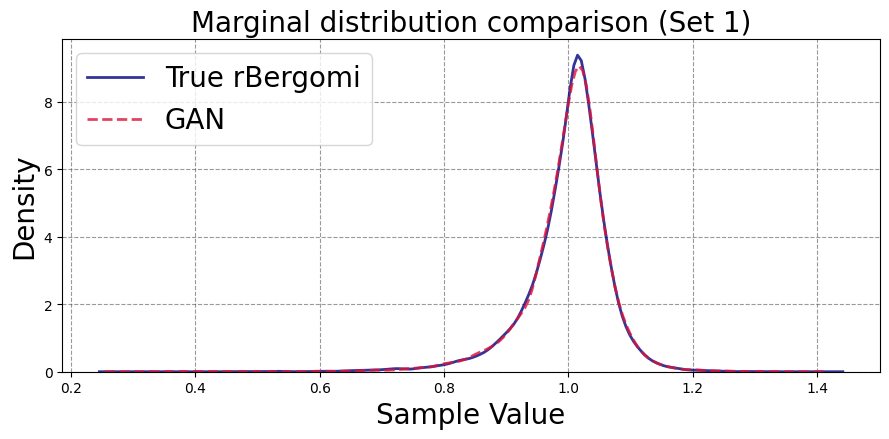


📌 Parameter set 2
    α = -0.450   η = 1.800   ρ = -0.900   ν₀ = 0.060   t₀ = 0.123   T = 0.329
    📏 Wasserstein distance: 0.0023


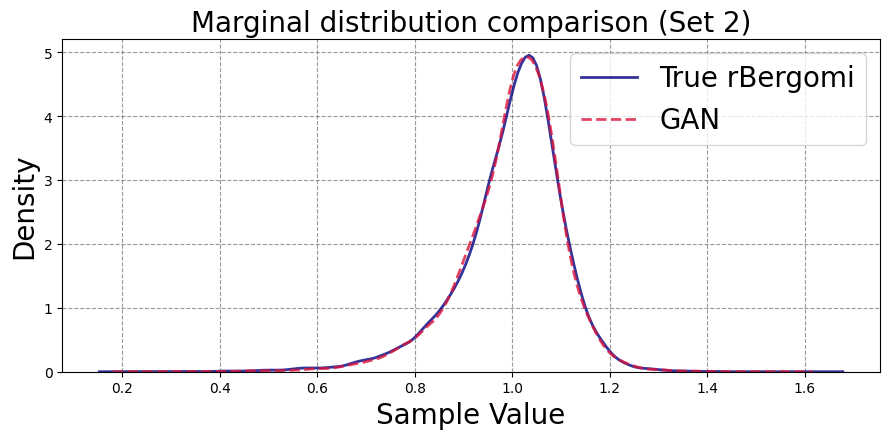


📌 Parameter set 3
    α = -0.350   η = 2.300   ρ = -0.400   ν₀ = 0.100   t₀ = 0.274   T = 0.411
    📏 Wasserstein distance: 0.0021


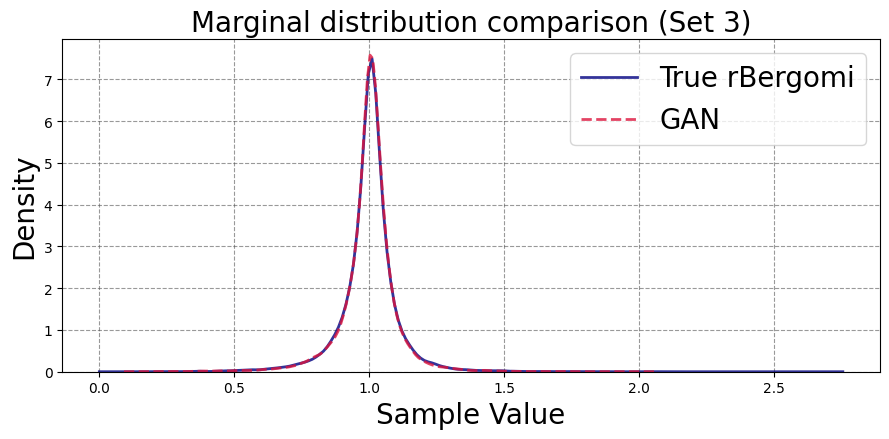


📌 Parameter set 4
    α = -0.250   η = 1.700   ρ = -0.600   ν₀ = 0.120   t₀ = 0.082   T = 0.493
    📏 Wasserstein distance: 0.0042


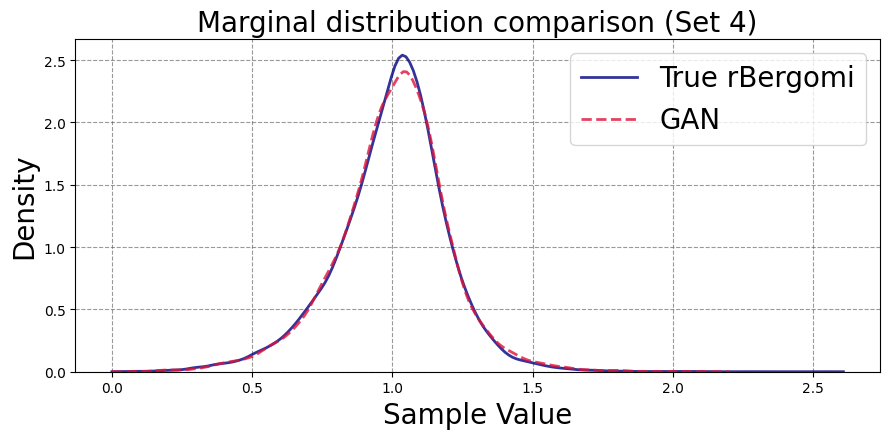


📌 Parameter set 5
    α = -0.400   η = 2.500   ρ = -0.700   ν₀ = 0.100   t₀ = 0.192   T = 0.274
    📏 Wasserstein distance: 0.0012


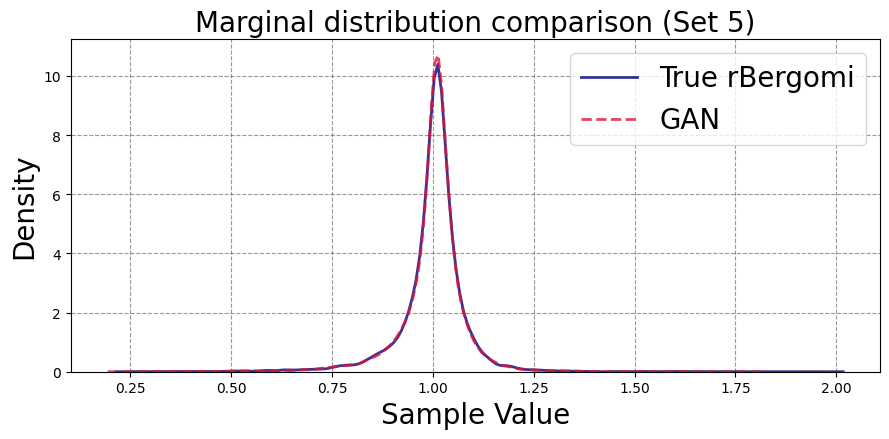


📌 Parameter set 6
    α = -0.400   η = 1.500   ρ = -0.800   ν₀ = 0.020   t₀ = 0.137   T = 0.411
    📏 Wasserstein distance: 0.0010


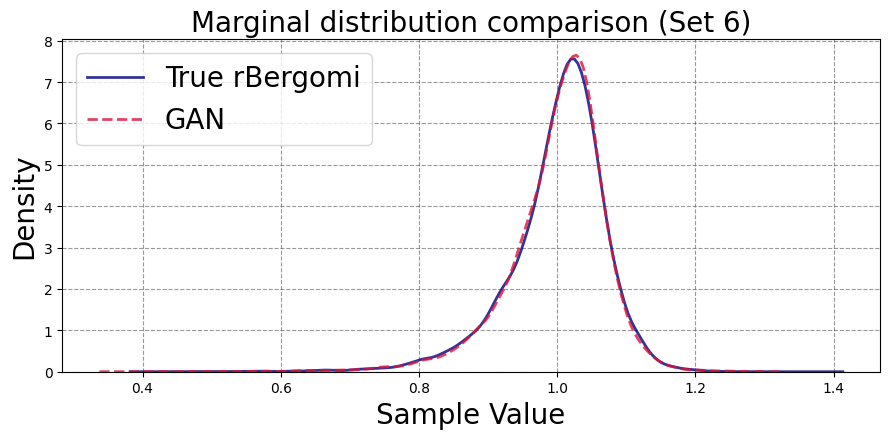

In [12]:
import torch
from datetime import date

typical_params = torch.tensor([
    [-0.30, 2.0, -0.7, 0.03, 30/365, 90/365],
    [-0.45, 1.8, -0.9, 0.06, 45/365, 120/365],
    [-0.35, 2.3, -0.4, 0.1, 100/365,  150/365],
    [-0.25, 1.7, -0.6, 0.12, 30/365, 180/365],
    [-0.40, 2.5, -0.7, 0.10, 70/365,  100/365],
    [-0.40, 1.5, -0.8, 0.02, 50/365, 150/365],
], dtype=__dtype__, device=__device__)

show_marginal(
    model=model,
    dataset=typical_params,
    dtype=__dtype__,
    device=__device__
)


### Post-processing and vectorized distributional evaluation for rough Bergomi

This section defines the post-processing applied to raw generator outputs and the vectorized procedure used to evaluate distributional accuracy against the benchmark rough Bergomi simulator.

---

### Post-processing

The generator outputs raw samples interpreted as log-prices. For rough Bergomi, the post-processing only consists of exponentiation:

$$
S = \exp(X).
$$

The function `RBergomi_postprocess` applies this map and reshapes the output into a tensor of size $B \times N_{\text{traj}}$, where $B$ is the number of parameter sets in the batch.

---

### Vectorized distributional evaluation

The function `evaluate_distributional_distance_vectorized` compares the model outputs with a reference process over a set of parameter configurations.

For each batch of parameters, the procedure:
- generates $N_{\text{traj}}$ samples from the reference simulator,
- generates $N_{\text{traj}}$ samples from the generator using random noise,
- applies the same post-processing to both outputs,
- clips values to a fixed cap for numerical stability.

Optional normalization can be enabled for GAN inputs. In that case, physical parameters are transformed before being fed to the generator, while the reference simulation always uses the original physical parameters.

Let $S^{\text{true}}$ and $S^{\text{model}}$ denote the post-processed samples.

#### Moment errors

The mean and standard deviation are compared through absolute and relative errors.

#### Distributional distances

The 1-Wasserstein distance is approximated using sorted samples:

$$
W_1
=
\frac{1}{N_{\text{traj}}}
\sum_{j=1}^{N_{\text{traj}}}
\big| S^{\text{true}}_{(j)} - S^{\text{model}}_{(j)} \big|.
$$

The Kolmogorov–Smirnov distance is estimated from empirical cumulative distribution functions:

$$
\mathrm{KS}
=
\sup_x
\big| F^{\text{true}}(x) - F^{\text{model}}(x) \big|.
$$

All metrics are aggregated across batches, and the function reports mean values, standard deviations, and worst-case errors over the parameter space.

---

### Output

The function returns:
- a dictionary of global summary metrics,
- the batch-wise means for the reference process,
- the batch-wise means for the model outputs.


In [13]:
import torch
from scipy.stats import wasserstein_distance as w1


def RBergomi_postprocess(raw_output: torch.Tensor,
                        param_batch: torch.Tensor,
                        N_traj: int) -> torch.Tensor:
    """
    Apply exponentiation to raw GAN outputs from the Heston model.

    Parameters:
    - raw_output: Tensor of shape (B * N_traj,) — the raw output of the generator (log-prices)
    - param_batch: Tensor of shape (B, D) — not used in Heston postprocessing
    - N_traj: number of samples per parameter set

    Returns:
    - Tensor of shape (B, N_traj): the exponentiated outputs
    """
    B = param_batch.shape[0]
    return torch.exp(raw_output).view(B, N_traj)

def evaluate_distributional_distance_vectorized(
    model,
    param_tensor: torch.Tensor,
    N_traj: int = 10000,
    batch_size: int = 512,
    noise_size: int = 5,
    cap: float = 3.0,
    device: str = __device__,
    dtype: torch.dtype = torch.float32,
    multi_gpu: bool = True,
    reference_process=None,
    postprocess=None,
    dt: float = 0.001,
    normalize: bool = False,
    normalizer_path: str = None,
    normalizer_method: str = "zscore"
):
    """
    Evaluate the distributional distance between a model and a reference process over a parameter tensor.
    Supports optional normalization using a Normalizer saved in JSON format.

    Returns:
    - final: Dictionary of global metrics (means, std, errors, distances)
    - true_means: List of batch-wise mean tensors of reference process
    - model_means: List of batch-wise mean tensors of GAN output
    """
    assert reference_process is not None, "A reference process must be provided."
    device = device
    param_tensor = param_tensor.to(dtype=dtype, device=device)
    model = model.to(device).eval()

    # Optional normalization
    if normalize:
        assert normalizer_path is not None, "Normalizer path must be provided if normalize=True."
        normalizer = Normalizer(method=normalizer_method)
        normalizer.load(normalizer_path, device=device, dtype=dtype)
        param_tensor_norm = normalizer.transform(param_tensor)
    else:
        param_tensor_norm = param_tensor

    eps = 1e-6
    N_param = param_tensor.size(0)

    # Containers for statistics
    true_means, model_means = [], []
    abs_errors, rel_errors = {k: [] for k in ["mean", "std"]}, {k: [] for k in ["mean", "std"]}
    ks_list, wass_list = [], []

    for i in range(0, N_param, batch_size):
        p_batch = param_tensor[i:i + batch_size]
        p_norm_batch = param_tensor_norm[i:i + batch_size]
        B = p_batch.size(0)

        p_expanded = p_norm_batch.unsqueeze(1).expand(B, N_traj, -1).reshape(B * N_traj, -1)

        with torch.no_grad():
            # Reference process
            columns = [p_batch[:, j].repeat_interleave(N_traj).to(device) for j in range(p_batch.shape[1])]
            raw_true = reference_process(*columns, dt=dt, dtype=dtype, device=device)

            if postprocess is not None:
                S_true = postprocess(raw_true.view(-1), p_batch, N_traj).clamp(1e-5, cap)
            else:
                S_true = raw_true.view(B, N_traj).clamp(1e-5, cap)

            # GAN output
            noise = torch.rand(B * N_traj, noise_size, dtype=dtype, device=device)
            input_tensor = torch.cat([noise, p_expanded], dim=1)
            raw_output = model(input_tensor).view(B * N_traj)

            if postprocess is not None:
                S_model = postprocess(raw_output, p_batch, N_traj).clamp(1e-5, cap)
            else:
                S_model = raw_output.view(B, N_traj).clamp(1e-5, cap)

        # Means and standard deviations
        true_mean = S_true.mean(dim=1)
        model_mean = S_model.mean(dim=1)
        true_std = S_true.std(dim=1)
        model_std = S_model.std(dim=1)

        true_means.append(true_mean.cpu())
        model_means.append(model_mean.cpu())

        abs_errors["mean"].append(torch.abs(model_mean - true_mean).cpu())
        abs_errors["std"].append(torch.abs(model_std - true_std).cpu())

        rel_errors["mean"].append((torch.abs(model_mean - true_mean) / (torch.abs(true_mean) + eps)).cpu())
        rel_errors["std"].append((torch.abs(model_std - true_std) / (torch.abs(true_std) + eps)).cpu())

        # Wasserstein-1 distance
        sorted_true, _ = torch.sort(S_true, dim=1)
        sorted_model, _ = torch.sort(S_model, dim=1)
        wass1 = torch.mean(torch.abs(sorted_true - sorted_model), dim=1)
        wass_list.append(wass1.cpu())

        # Kolmogorov-Smirnov distance (histogram-based)
        hist_true = torch.stack([torch.histc(x, bins=1000, min=0, max=cap) for x in S_true])
        hist_model = torch.stack([torch.histc(x, bins=1000, min=0, max=cap) for x in S_model])
        ecdf_true = torch.cumsum(hist_true, dim=1) / N_traj
        ecdf_model = torch.cumsum(hist_model, dim=1) / N_traj
        ks, _ = torch.max(torch.abs(ecdf_true - ecdf_model), dim=1)
        ks_list.append(ks.cpu())

    # Stack all collected statistics
    true_means_all = torch.cat(true_means)
    model_means_all = torch.cat(model_means)

    final = {
        "true_mean": true_means_all.mean().item(),
        "true_mean_std": true_means_all.std().item(),
        "true_mean_worst": true_means_all[torch.argmax(torch.abs(true_means_all - true_means_all.mean()))].item(),

        "model_mean": model_means_all.mean().item(),
        "model_mean_std": model_means_all.std().item(),
        "model_mean_worst": model_means_all[torch.argmax(torch.abs(model_means_all - model_means_all.mean()))].item(),
    }

    # Absolute and relative errors
    for err_type, container in zip(["abs", "rel"], [abs_errors, rel_errors]):
        for key in container:
            values = torch.cat(container[key])
            final[f"{err_type}_error_{key}_mean"] = values.mean().item()
            final[f"{err_type}_error_{key}_std"] = values.std().item()
            final[f"{err_type}_error_{key}_worst"] = values.max().item()

    # Distance metrics
    ks_all = torch.cat(ks_list)
    wass_all = torch.cat(wass_list)
    final["ks_distance_mean"] = ks_all.mean().item()
    final["ks_distance_std"] = ks_all.std().item()
    final["ks_distance_worst"] = ks_all.max().item()

    final["wasserstein_1_mean"] = wass_all.mean().item()
    final["wasserstein_1_std"] = wass_all.std().item()
    final["wasserstein_1_worst"] = wass_all.max().item()

    return final, true_means, model_means


### Distributional evaluation over random rough Bergomi parameters

This experiment evaluates the distributional accuracy of the trained generator over randomly sampled rough Bergomi parameter configurations.

Parameter vectors are drawn uniformly within the training ranges for $\alpha$, $\eta$, $\rho$, $v_0$, and $T$. For each configuration, the model output distribution is compared to the benchmark rough Bergomi simulator using moment errors and distributional distances. The results are aggregated into a summary table reporting mean, standard deviation, and worst-case statistics across the parameter space.

---

### ⚠️ Important note on experimental scale

The results reported in the associated paper are obtained using large-scale experiments with:
- $n_{\text{simu}} = 100\,000$ parameter configurations,
- $N_{\text{traj}} = 100\,000$ samples per configuration.

In this notebook, we deliberately use reduced values $n_{\text{simu}} = 100$ and $N_{\text{traj}} = 10\,000$ to ensure that the code can run on standard hardware within a reasonable execution time.

These reduced settings are intended for demonstration and reproducibility only and should not be interpreted as the final quantitative results reported in the paper.

---

### Output

The summary table is exported to CSV and LaTeX formats for direct inclusion in reports and manuscripts.


In [14]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

# ⚙️ Paramètres du modèle rough Bergomi
params = {
    "nb_simu": 100,
    "ALPHAS": [-0.49, -0.1],
    "ETAS": [1.0, 3.0],
    "RHOS": [-0.9, -0.3],
    "v0": [0.01, 0.12],
    "T": [30/365, 180/365],
    "dt": 0.001,
    "t0":True,
    "min_dt": 30/365,
    "fixed_dt": False,
    "cap": 3.0,
    "dtype": __dtype__,
    "device": __device__,
    "normalize": False,
}

# 🧪 Génération aléatoire des paramètres (batch)
D = rBergomi_param(random_param=True, **params).params

# 🧮 Évaluation du modèle vs simulateur exact
results, true_means, model_means = evaluate_distributional_distance_vectorized(
    model=model,
    param_tensor=D,
    N_traj=10_000,
    batch_size=1,
    noise_size=5,
    device="cuda",
    multi_gpu=True,
    reference_process=rBergomi,
    postprocess=RBergomi_postprocess,
    normalize=params["normalize"]
)

# 📊 Construction du tableau de résultats
table = []

# 1. Moyennes "true" et "model"
for base in ["true_mean", "model_mean"]:
    table.append({
        "Metric": base,
        "Mean": results[base],
        "Worst case": results.get(f"{base}_worst", None),
        "Std": results.get(f"{base}_std", None)
    })

# 2. Clés à ignorer (déjà traitées)
skip_keys = [
    "true_mean", "model_mean",
    "true_mean_std", "model_mean_std",
    "true_mean_worst", "model_mean_worst"
]

# 3. Ajout des autres métriques
for metric, value in results.items():
    if metric in skip_keys:
        continue

    if metric.endswith("_mean"):
        base = metric[:-5]
        std_key = base + "_std"
        worst_key = base + "_worst"
        std_val = results.get(std_key, None)
        worst_val = results.get(worst_key, None)

        if base.startswith("rel_error_"):
            value *= 100
            if std_val is not None:
                std_val *= 100
            if worst_val is not None:
                worst_val *= 100

        table.append({
            "Metric": base,
            "Mean": value,
            "Worst case": worst_val,
            "Std": std_val
        })

    elif any(metric.endswith(suffix) for suffix in ["_std", "_worst"]):
        continue

    else:
        table.append({
            "Metric": metric,
            "Mean": value,
            "Worst case": None,
            "Std": None
        })

# 📈 Formatage final
df = pd.DataFrame(table)
df = df[["Metric", "Mean", "Worst case", "Std"]]
df.set_index("Metric", inplace=True)
df = df.round(6)


print("📊 Modèle rough Bergomi – Résumé des distances distributionnelles (% pour erreurs relatives) :")
display(
    df.style.set_caption("rough Bergomi model – Moment Errors and Distances")
      .format(precision=3)
      .background_gradient(subset=["Mean"], cmap="Purples", low=0.2, high=0.6)
)



📊 Modèle rough Bergomi – Résumé des distances distributionnelles (% pour erreurs relatives) :


,Mean,Worst case,Std
Metric,,,
true_mean,1.000,1.002,0.001
model_mean,1.000,0.997,0.001
abs_error_mean,0.001,0.003,0.001
abs_error_std,0.002,0.012,0.002
rel_error_mean,0.136,0.346,0.097
rel_error_std,2.604,11.111,2.543
ks_distance,0.015,0.025,0.005
wasserstein_1,0.002,0.005,0.001
